<a href="https://colab.research.google.com/github/nethra-prabhu/DLL/blob/main/Programs5_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 57s 155ms/step - accuracy: 0.5593 - loss: 0.6800 - val_accuracy: 0.5604 - val_loss: 0.6652
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 156ms/step - accuracy: 0.6533 - loss: 0.6297 - val_accuracy: 0.7672 - val_loss: 0.5216
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 55s 157ms/step - accuracy: 0.6813 - loss: 0.5611 - val_accuracy: 0.6656 - val_loss: 0.5606
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 155ms/step - accuracy: 0.8315 - loss: 0.4322 - val_accuracy: 0.8248 - val_loss: 0.4391
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 158ms/step - accuracy: 0.8603 - loss: 0.3699 - val_accuracy: 0.8336 - val_loss: 0.4247
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.8266 - loss: 0.4430
Accuracy: 0.8266


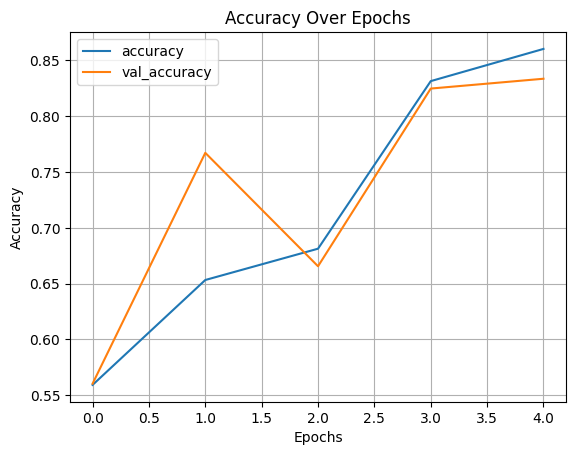

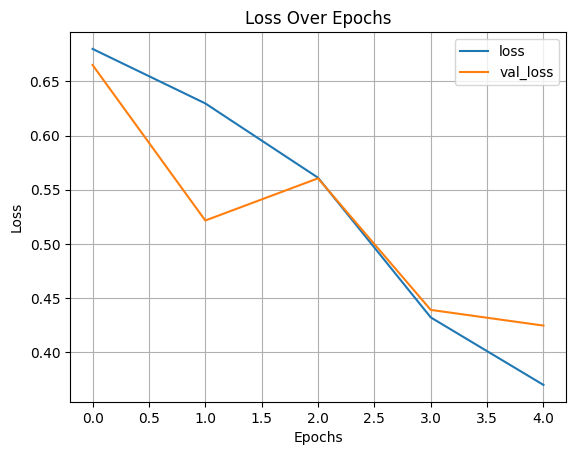

In [2]:
# Program 5
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences

(x_train, y_train), (x_test, y_test) = datasets.imdb.load_data(num_words=10000)
x_train = pad_sequences(x_train, maxlen=200, padding='post')
x_test = pad_sequences(x_test, maxlen=200, padding='post')

model = models.Sequential([
    layers.Input((200,)),
    layers.Embedding(10000, 64),
    layers.LSTM(64),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

loss, acc = model.evaluate(x_test, y_test)
print(f'Accuracy: {acc:.4f}')

for metric in ['accuracy', 'loss']:
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric])
  plt.xlabel('Epochs')
  plt.ylabel(metric.capitalize())
  plt.title(f'{metric.capitalize()} Over Epochs')
  plt.grid(True)
  plt.legend([metric, 'val_'+metric])
  plt.show()

In [4]:
# Program 6
import numpy as np
from tensorflow.keras import layers, models, optimizers

starts = np.random.randint(0,100,1000)
seqs = (starts[:, None] + np.arange(10)).astype('float32')[..., None]
x, y = seqs[:, :-1], seqs[:, 1:]

def train(rnn):
  model = models.Sequential([layers.Input((9,1)), rnn, layers.Dense((1))])
  model.compile(optimizer=optimizers.Adam(0.01), loss='mse')
  return model.fit(x, y, epochs=50, verbose=0).history['loss']

losses = {
    'RNN': train(layers.SimpleRNN(32, return_sequences=True)),
    'BiRNN': train(layers.Bidirectional(layers.SimpleRNN(32, return_sequences=True)))
}

for name, loss in losses.items():
  print(f'Final Loss: ({name}): {loss[-1]:.4f}')

Final Loss: (RNN): 0.9036
Final Loss: (BiRNN): 0.2755


In [5]:
# Program 7
import numpy as np
from tensorflow.keras import layers, models

x = np.random.rand(1000, 5, 1)
y = np.flip(x, axis=1)

enc_in = layers.Input((5,1))
_, h, c = layers.LSTM(32, return_state=True)(enc_in)

dec_in = layers.Input((5,1))
dec_out = layers.LSTM(32, return_sequences=True)(dec_in, initial_state=[h, c])
out = layers.Dense(1)(dec_out)

model = models.Model([enc_in, dec_in], out)
model.compile(optimizer='adam', loss='mse')
model.fit([x,y], y, epochs=10, batch_size=32)

pred = model.predict([x[:1], y[:1]])
print('Input:\n', x[0].squeeze())
print('Predicted reversed:\n', pred[0].squeeze())
print('True reversed:\n', y[0].squeeze())

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1924
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0690
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0623
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0577
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0528
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0472
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0406
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0324
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0222
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0102
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
Input:
 [0.50608826 0.49608275 0.66958017 0.28776236 0.43196646]
Predicted reversed:
 [0.44103196 0.35241345 0.64357924 0.49618018 0.5211529 ]
True reversed:
 [0.43196646 0.28776236 0.66958017 0.49608275 0.50608826]


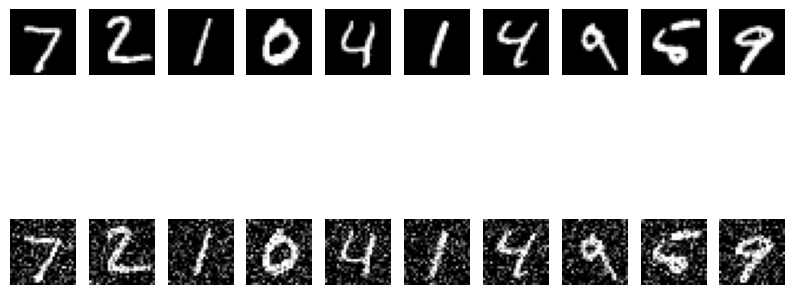

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 207s 871ms/step - loss: 0.1680 - val_loss: 0.0972
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 189s 805ms/step - loss: 0.0932 - val_loss: 0.0883
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 198s 841ms/step - loss: 0.0874 - val_loss: 0.0849
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 205s 872ms/step - loss: 0.0847 - val_loss: 0.0829
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 186s 791ms/step - loss: 0.0831 - val_loss: 0.0817
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step


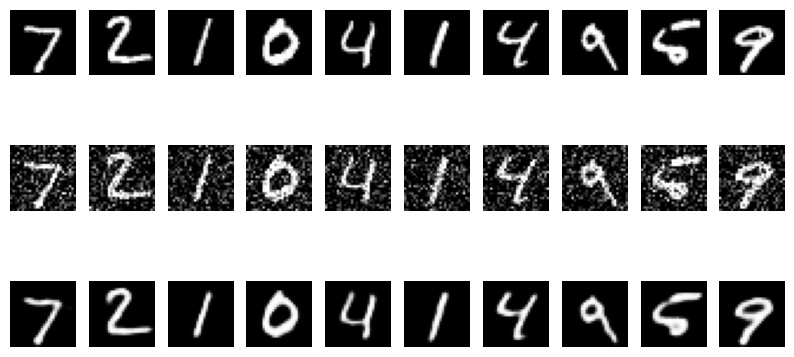

In [7]:
# Program 9
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models, datasets

(x_train, _), (x_test, _) = datasets.mnist.load_data()
x_train, x_test = x_train[..., None] / 255, x_test[..., None] / 255

def add_noise(x):
  return np.clip(x + 0.3 * np.random.normal(size=x.shape), 0, 1)

def show(rows):
  plt.figure(figsize=(10, 5))
  for r, imgs in enumerate(rows):
    for i in range(10):
      plt.subplot(len(rows), 10, r * 10 + i + 1)
      plt.imshow(imgs[i].squeeze(), cmap='gray')
      plt.axis('off')
  plt.show()

x_train_noisy, x_test_noisy = add_noise(x_train), add_noise(x_test)
show([x_test, x_test_noisy])

model = models.Sequential([
    layers.Input((28, 28, 1)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(padding='same'),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(padding='same'),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.UpSampling2D(),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.UpSampling2D(),
    layers.Conv2D(1, 3, activation='sigmoid', padding='same')
])

model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(x_train_noisy, x_train, epochs=5, batch_size=256, validation_data=(x_test_noisy, x_test))

show([x_test, x_test_noisy, model.predict(x_test_noisy)])